# Lab Problem Statement 6: Statistical Analysis of Physical Characteristics of Palmer Penguins

**Topics:** Descriptive Statistics, Hypothesis Testing, ANOVA & Non-Parametric Tests

## Objective

This laboratory analyzes whether physical characteristics of Palmer Archipelago penguins differ significantly across species and sex. The analysis includes descriptive statistics, hypothesis testing, confidence intervals, effect-size estimation, one-way ANOVA, Tukey HSD, Kruskal-Wallis testing, two-way ANOVA, and flipper-length analysis.

### Dataset

Palmer Penguins Dataset — UCI Machine Learning Repository, Dataset ID 690.

The dataset contains 344 penguins belonging to three species: Adélie, Chinstrap, and Gentoo.

### Main Variables

- `species` — penguin species
- `island` — island where the penguin was observed
- `bill_length_mm` — bill length in millimetres
- `bill_depth_mm` — bill depth in millimetres
- `flipper_length_mm` — flipper length in millimetres
- `body_mass_g` — body mass in grams
- `sex` — penguin sex


In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "datasets"

## 1. Install and Load Required R Packages

The notebook uses `tidyverse` for data manipulation and visualization, `moments` for skewness and kurtosis, `car` for Levene's test, and `effectsize` for Cohen's *d*.

In [2]:
required_packages <- c("tidyverse", "moments", "car", "effectsize", "broom", "knitr")

installed <- rownames(installed.packages())
for (pkg in required_packages) {
  if (!(pkg %in% installed)) {
    install.packages(pkg, repos = "https://cloud.r-project.org")
  }
}

library(tidyverse)
library(moments)
library(car)
library(effectsize)
library(broom)
library(knitr)

options(scipen = 999)
theme_set(theme_minimal(base_size = 13))

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




## 2. Load the Palmer Penguins Dataset

The UCI Palmer Penguins dataset contains 344 observations. The analysis uses the simplified measurement variables required by the laboratory problem.

In [3]:
data_url <- "https://raw.githubusercontent.com/mcnakhaee/palmerpenguins/master/palmerpenguins/data/penguins.csv"

penguins <- read.csv(data_url, stringsAsFactors = FALSE, na.strings = c("NA", ""))

penguins <- penguins %>%
  mutate(
    species = factor(species),
    island = factor(island),
    sex = factor(sex),
    year = factor(year)
  )

cat("Number of observations:", nrow(penguins), "\n")
cat("Number of variables:", ncol(penguins), "\n")

head(penguins)

Number of observations: 344 
Number of variables: 8 


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<fct>
1,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
2,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
3,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
4,Adelie,Torgersen,NA,NA,NA,NA,NA,2007
5,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
6,Adelie,Torgersen,39.3,20.6,190,3650,male,2007


In [4]:
str(penguins)
        
        summary(penguins)

'data.frame':	344 obs. of  8 variables:
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num  39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num  18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int  181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int  3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : Factor w/ 3 levels "2007","2008",..: 1 1 1 1 1 1 1 1 1 1 ...


      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NA's   :2       NA's   :2      
 flipper_length_mm  body_mass_g       sex        year    
 Min.   :172.0     Min.   :2700   female:165   2007:110  
 1st Qu.:190.0     1st Qu.:3550   male  :168   2008:114  
 Median :197.0     Median :4050   NA's  : 11   2009:120  
 Mean   :200.9     Mean   :4202                          
 3rd Qu.:213.0     3rd Qu.:4750                          
 Max.   :231.0     Max.   :6300                          
 NA's   :2         NA's   :2                             

## 3. Data Cleaning and Missing Values

The UCI dataset is documented as having no missing values at the repository level, while the commonly distributed simplified CSV contains missing measurements for some records. Therefore, missing observations are explicitly examined before each analysis.

In [5]:
missing_summary <- data.frame(
  Variable = names(penguins),
  Missing = sapply(penguins, function(x) sum(is.na(x))),
  Missing_Percent = round(sapply(penguins, function(x) mean(is.na(x))) * 100, 2)
)

kable(missing_summary, caption = "Missing-value summary")



Table: Missing-value summary

|                  |Variable          | Missing| Missing_Percent|
|:-----------------|:-----------------|-------:|---------------:|
|species           |species           |       0|            0.00|
|island            |island            |       0|            0.00|
|bill_length_mm    |bill_length_mm    |       2|            0.58|
|bill_depth_mm     |bill_depth_mm     |       2|            0.58|
|flipper_length_mm |flipper_length_mm |       2|            0.58|
|body_mass_g       |body_mass_g       |       2|            0.58|
|sex               |sex               |      11|            3.20|
|year              |year              |       0|            0.00|

# 4. Descriptive Statistical Analysis

The following statistics are calculated for `body_mass_g`, overall and separately for each penguin species:

- Mean
- Median
- Minimum and maximum
- Variance
- Standard deviation
- First and third quartiles
- Interquartile range
- Skewness
- Kurtosis

In [6]:
body_mass_stats <- function(x) {
  x <- x[!is.na(x)]
  data.frame(
    N = length(x),
    Mean = mean(x),
    Median = median(x),
    Minimum = min(x),
    Q1 = quantile(x, 0.25),
    Q3 = quantile(x, 0.75),
    Maximum = max(x),
    Variance = var(x),
    SD = sd(x),
    IQR = IQR(x),
    Skewness = skewness(x),
    Kurtosis = kurtosis(x)
  )
}

overall_stats <- body_mass_stats(penguins$body_mass_g)
overall_stats

,N,Mean,Median,Minimum,Q1,Q3,Maximum,Variance,SD,IQR,Skewness,Kurtosis
,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
25%,342,4201.754,4050,2700,3550,4750,6300,643131.1,801.9545,1200,0.468264,2.273757


In [7]:
species_stats <- penguins %>%
  group_by(species) %>%
  summarise(
    N = sum(!is.na(body_mass_g)),
    Mean = mean(body_mass_g, na.rm = TRUE),
    Median = median(body_mass_g, na.rm = TRUE),
    Minimum = min(body_mass_g, na.rm = TRUE),
    Q1 = quantile(body_mass_g, 0.25, na.rm = TRUE),
    Q3 = quantile(body_mass_g, 0.75, na.rm = TRUE),
    Maximum = max(body_mass_g, na.rm = TRUE),
    Variance = var(body_mass_g, na.rm = TRUE),
    SD = sd(body_mass_g, na.rm = TRUE),
    IQR = IQR(body_mass_g, na.rm = TRUE),
    Skewness = skewness(body_mass_g, na.rm = TRUE),
    Kurtosis = kurtosis(body_mass_g, na.rm = TRUE),
    .groups = "drop"
  )

species_stats %>%
  mutate(across(where(is.numeric), ~ round(.x, 3))) %>%
  kable(caption = "Descriptive statistics of body mass by species")



Table: Descriptive statistics of body mass by species

|species   |   N|     Mean| Median| Minimum|     Q1|   Q3| Maximum| Variance|      SD|   IQR| Skewness| Kurtosis|
|:---------|---:|--------:|------:|-------:|------:|----:|-------:|--------:|-------:|-----:|--------:|--------:|
|Adelie    | 151| 3700.662|   3700|    2850| 3350.0| 4000|    4775| 210282.9| 458.566| 650.0|    0.282|    2.406|
|Chinstrap |  68| 3733.088|   3700|    2700| 3487.5| 3950|    4800| 147713.5| 384.335| 462.5|    0.242|    3.464|
|Gentoo    | 123| 5076.016|   5000|    3950| 4700.0| 5500|    6300| 254133.2| 504.116| 800.0|    0.069|    2.258|

## Interpretation of Descriptive Statistics

The descriptive statistics allow comparison of central tendency and variability among Adélie, Chinstrap, and Gentoo penguins. Differences in means and medians provide an initial indication of species-level variation, while standard deviation and IQR describe within-species variability. Skewness and kurtosis provide information about departures from a symmetric normal distribution.

# 5. Visualization of Body Mass

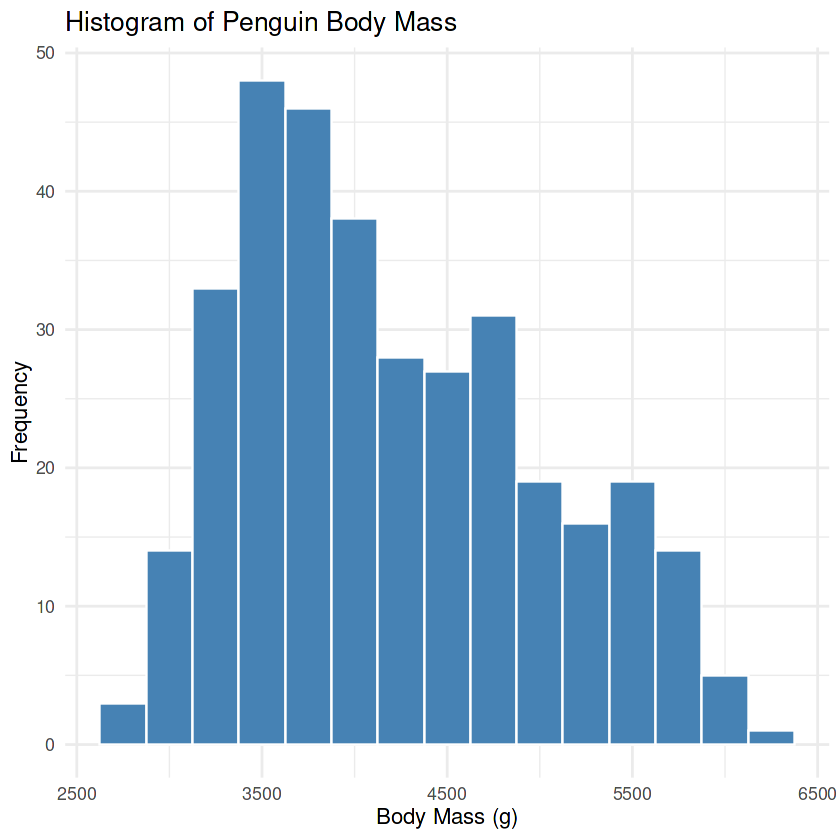

In [8]:
ggplot(penguins, aes(x = body_mass_g)) +
  geom_histogram(binwidth = 250, fill = "steelblue", color = "white", na.rm = TRUE) +
  labs(
    title = "Histogram of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Frequency"
  )

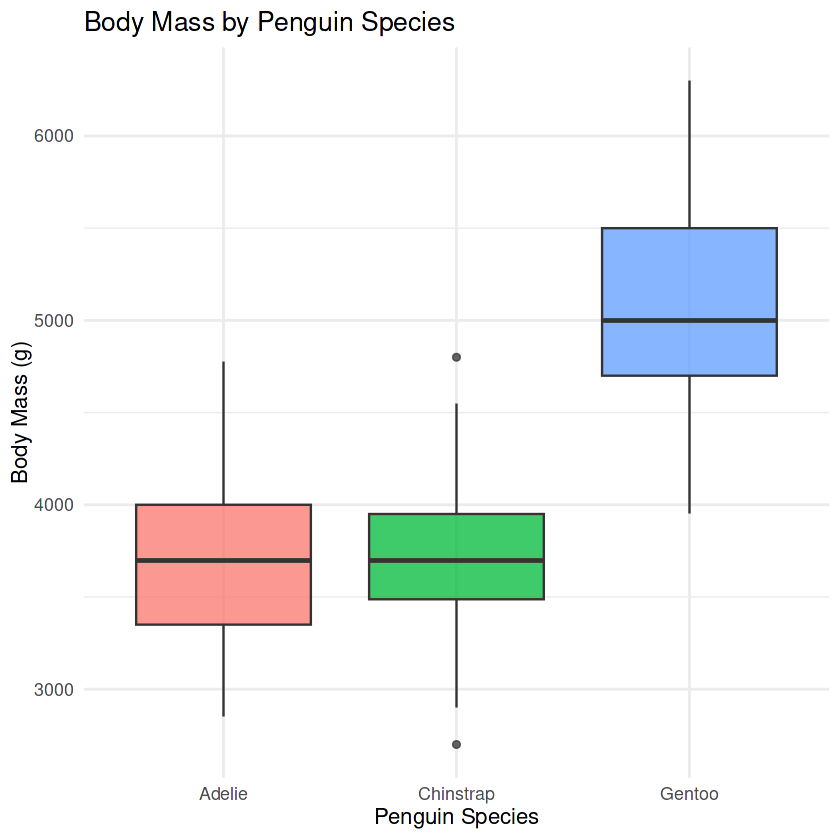

In [9]:
ggplot(penguins, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot(alpha = 0.75, na.rm = TRUE) +
  labs(
    title = "Body Mass by Penguin Species",
    x = "Penguin Species",
    y = "Body Mass (g)"
  ) +
  theme(legend.position = "none")

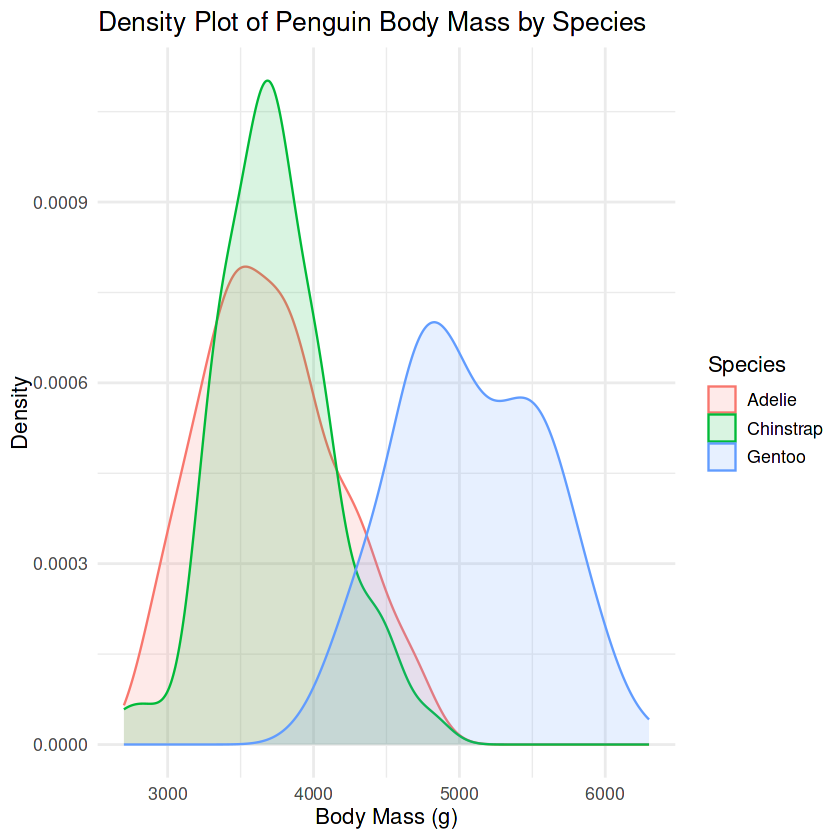

In [10]:
ggplot(penguins, aes(x = body_mass_g, color = species, fill = species)) +
  geom_density(alpha = 0.15, na.rm = TRUE) +
  labs(
    title = "Density Plot of Penguin Body Mass by Species",
    x = "Body Mass (g)",
    y = "Density",
    color = "Species",
    fill = "Species"
  )

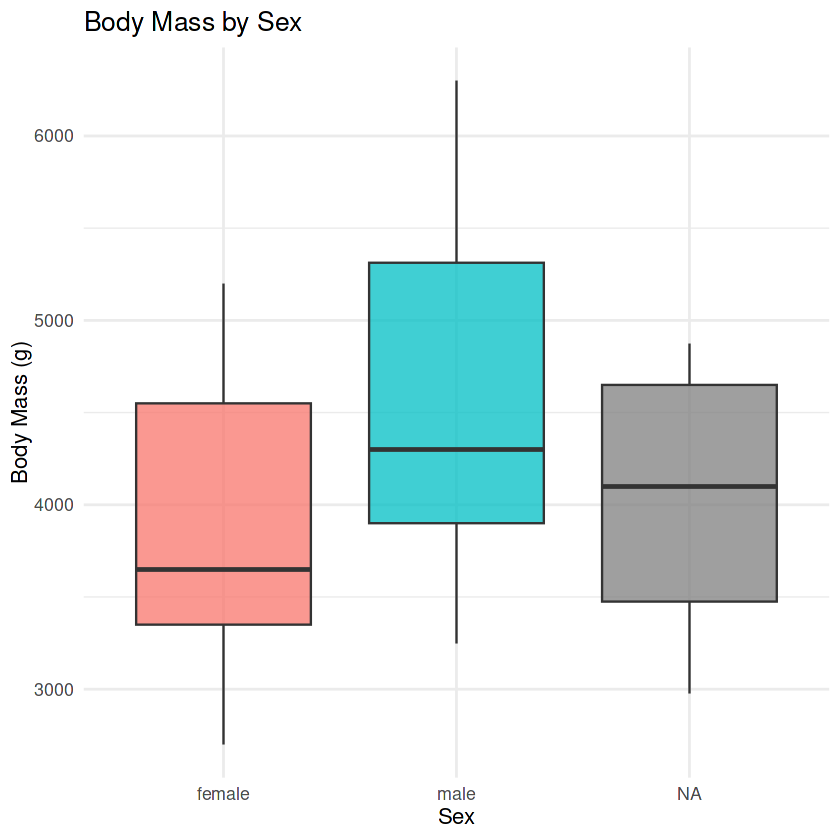

In [11]:
ggplot(penguins, aes(x = sex, y = body_mass_g, fill = sex)) +
  geom_boxplot(alpha = 0.75, na.rm = TRUE) +
  labs(
    title = "Body Mass by Sex",
    x = "Sex",
    y = "Body Mass (g)"
  ) +
  theme(legend.position = "none")

# 6. Hypothesis Testing: Male vs Female Body Mass

### Hypotheses

**Null hypothesis (H₀):** The mean body mass of male penguins equals the mean body mass of female penguins.

**Alternative hypothesis (H₁):** The mean body mass of male penguins differs from the mean body mass of female penguins.

A two-sided independent two-sample t-test is used.

In [12]:
sex_mass <- penguins %>%
  filter(!is.na(body_mass_g), !is.na(sex))

sex_summary <- sex_mass %>%
  group_by(sex) %>%
  summarise(
    N = n(),
    Mean = mean(body_mass_g),
    SD = sd(body_mass_g),
    Median = median(body_mass_g),
    .groups = "drop"
  )

kable(sex_summary, digits = 3, caption = "Body mass summary by sex")



Table: Body mass summary by sex

|sex    |   N|     Mean|      SD| Median|
|:------|---:|--------:|-------:|------:|
|female | 165| 3862.273| 666.172|   3650|
|male   | 168| 4545.685| 787.629|   4300|

## Normality Check: Shapiro-Wilk Test

The Shapiro-Wilk test is applied separately to male and female body masses. Because normality tests can be sensitive to sample size, the results are interpreted together with QQ-plots and the overall shape of the distributions.

In [13]:
shapiro_sex <- sex_mass %>%
  group_by(sex) %>%
  summarise(
    W = shapiro.test(body_mass_g)$statistic,
    p_value = shapiro.test(body_mass_g)$p.value,
    .groups = "drop"
  )

kable(shapiro_sex, digits = 5, caption = "Shapiro-Wilk normality tests by sex")



Table: Shapiro-Wilk normality tests by sex

|sex    |       W| p_value|
|:------|-------:|-------:|
|female | 0.91931|       0|
|male   | 0.92504|       0|

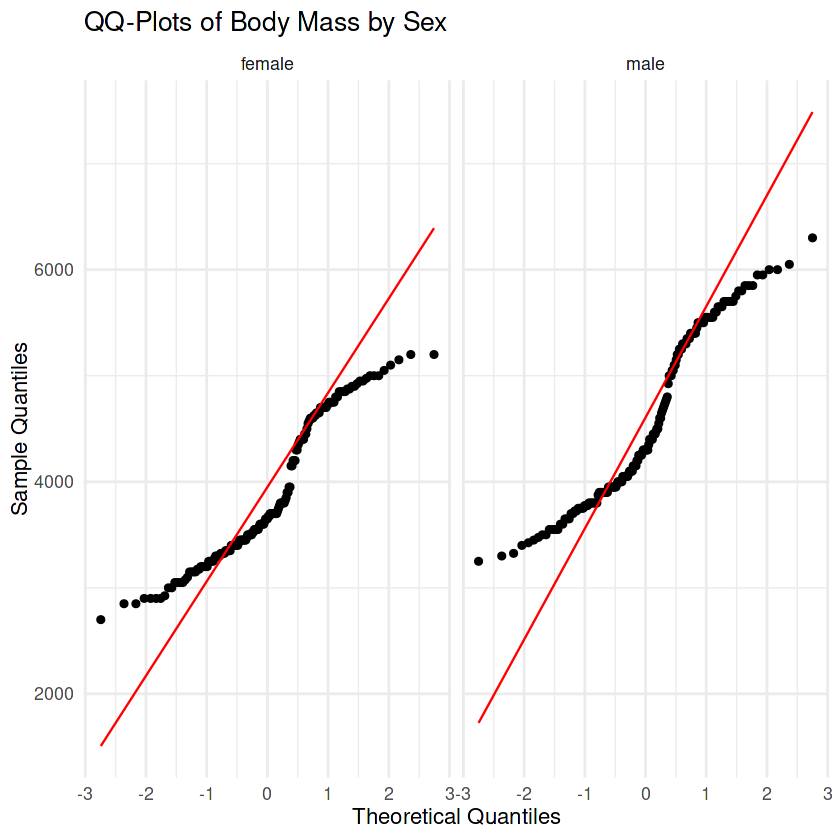

In [14]:
ggplot(sex_mass, aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line(color = "red") +
  facet_wrap(~ sex) +
  labs(
    title = "QQ-Plots of Body Mass by Sex",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  )

## Independent Two-Sample t-Test

Welch's t-test is used because it does not require equal population variances and is generally appropriate for comparing two independent groups.

In [15]:
t_test_sex <- t.test(
  body_mass_g ~ sex,
  data = sex_mass,
  var.equal = FALSE,
  conf.level = 0.95
)

t_test_sex


	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 0.0000000000000004794
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


In [16]:
cohen_d_sex <- cohens_d(
  body_mass_g ~ sex,
  data = sex_mass,
  pooled_sd = TRUE,
  ci = 0.95
)

cohen_d_sex

Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-0.9362048,0.95,-1.161904,-0.709225


### Interpretation

The t-test evaluates whether the difference between male and female mean body mass is statistically significant. The 95% confidence interval gives a plausible range for the population mean difference. Cohen's *d* quantifies the magnitude of the difference independently of sample size.

As a common guideline, |d| ≈ 0.2 is small, ≈ 0.5 is medium, and ≈ 0.8 or greater is large. These thresholds should be treated as approximate rather than absolute.

# 7. One-Way ANOVA: Body Mass by Species

### Hypotheses

**H₀:** The mean body mass is equal for all three penguin species.

**H₁:** At least one species has a different mean body mass.

The model is:

`body_mass_g ~ species`

In [17]:
species_mass <- penguins %>%
  filter(!is.na(body_mass_g), !is.na(species))

In [18]:
species_shapiro <- species_mass %>%
  group_by(species) %>%
  summarise(
    N = n(),
    W = shapiro.test(body_mass_g)$statistic,
    p_value = shapiro.test(body_mass_g)$p.value,
    .groups = "drop"
  )

kable(species_shapiro, digits = 5, caption = "Shapiro-Wilk tests by species")



Table: Shapiro-Wilk tests by species

|species   |   N|       W| p_value|
|:---------|---:|-------:|-------:|
|Adelie    | 151| 0.98071| 0.03240|
|Chinstrap |  68| 0.98449| 0.56051|
|Gentoo    | 123| 0.98593| 0.23362|

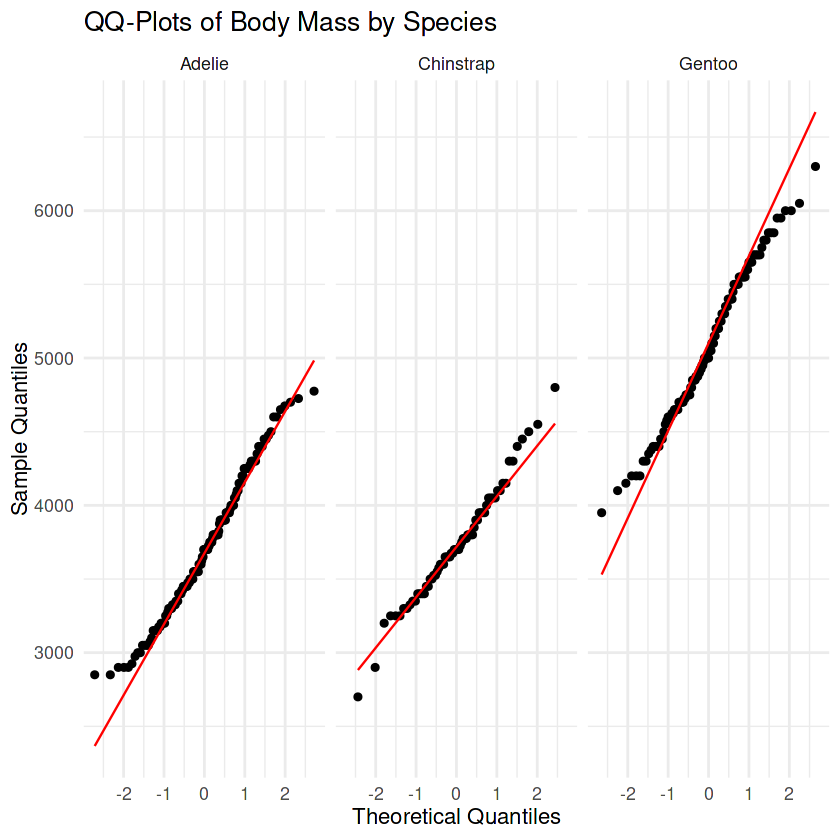

In [19]:
ggplot(species_mass, aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line(color = "red") +
  facet_wrap(~ species) +
  labs(
    title = "QQ-Plots of Body Mass by Species",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  )

## Homogeneity of Variance: Levene's Test

Levene's test examines whether the variance of body mass is approximately equal across species.

In [20]:
levene_species <- leveneTest(body_mass_g ~ species, data = species_mass)
levene_species

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.120251,0.006445083
,339,NA,NA


## One-Way ANOVA

In [21]:
anova_oneway <- aov(body_mass_g ~ species, data = species_mass)
summary(anova_oneway)

             Df    Sum Sq  Mean Sq F value              Pr(>F)    
species       2 146864214 73432107   343.6 <0.0000000000000002 ***
Residuals   339  72443483   213698                                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [22]:
anova_table <- broom::tidy(anova_oneway)
kable(anova_table, digits = 5, caption = "One-way ANOVA table for body mass")



Table: One-way ANOVA table for body mass

|term      |  df|     sumsq|     meansq| statistic| p.value|
|:---------|---:|---------:|----------:|---------:|-------:|
|species   |   2| 146864214| 73432107.1|  343.6263|       0|
|Residuals | 339|  72443483|   213697.6|        NA|      NA|

## Tukey HSD Post-Hoc Test

If the ANOVA is statistically significant, Tukey's HSD identifies which pairs of species have significantly different mean body masses.

In [23]:
tukey_species <- TukeyHSD(anova_oneway)
tukey_species

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = species_mass)

$species
                       diff       lwr       upr     p adj
Chinstrap-Adelie   32.42598 -126.5002  191.3522 0.8806666
Gentoo-Adelie    1375.35401 1243.1786 1507.5294 0.0000000
Gentoo-Chinstrap 1342.92802 1178.4810 1507.3750 0.0000000


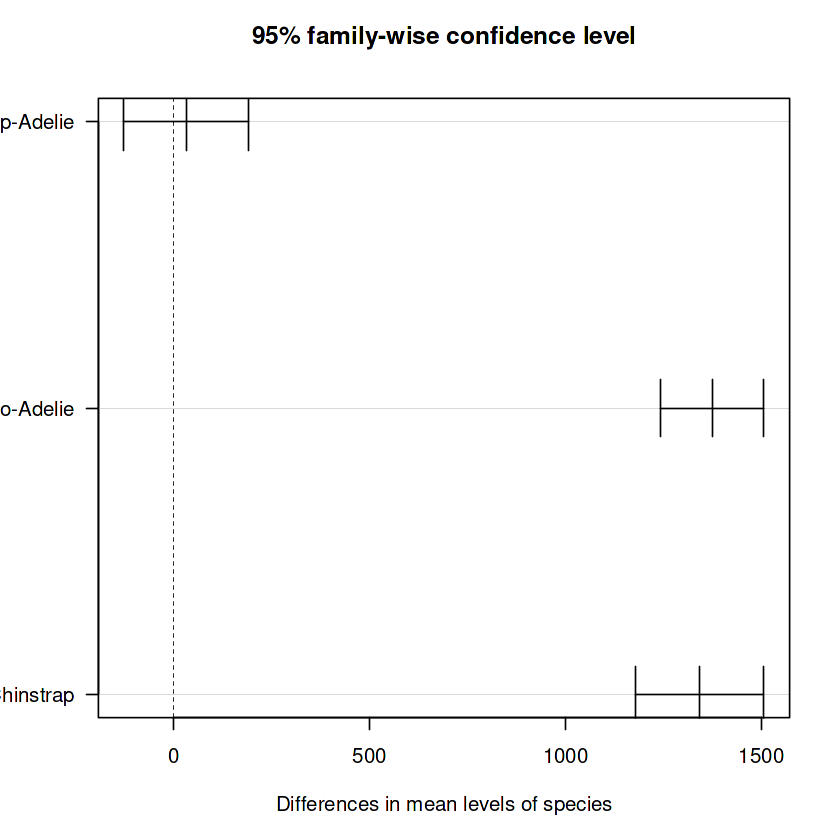

In [24]:
plot(tukey_species, las = 1)

# 8. Non-Parametric Analysis: Kruskal-Wallis Test

The Kruskal-Wallis test is used as a non-parametric alternative to one-way ANOVA when assumptions of normality and/or homogeneity of variance are substantially violated.

### Hypotheses

**H₀:** The distributions of body mass are the same across species.

**H₁:** At least one species has a different distribution.

In [25]:
kruskal_species <- kruskal.test(body_mass_g ~ species, data = species_mass)
kruskal_species


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 217.6, df = 2, p-value <
0.00000000000000022


## ANOVA vs Kruskal-Wallis

The one-way ANOVA tests differences in group means under its model assumptions, whereas Kruskal-Wallis compares the distributions/ranks across groups. If both tests produce very small p-values, they provide consistent evidence that body mass differs among penguin species.

The two methods should not be interpreted as testing exactly the same parameter. Their agreement strengthens the conclusion that there is a substantial species-level difference.

# 9. Two-Way ANOVA: Species and Sex

The two-way ANOVA investigates:

1. The main effect of species.
2. The main effect of sex.
3. The species × sex interaction.

The model is:

`body_mass_g ~ species * sex`

In [26]:
two_way_data <- penguins %>%
  filter(!is.na(body_mass_g), !is.na(species), !is.na(sex))

two_way_data %>%
  group_by(species, sex) %>%
  summarise(
    N = n(),
    Mean = mean(body_mass_g),
    SD = sd(body_mass_g),
    .groups = "drop"
  ) %>%
  kable(digits = 2, caption = "Body mass summary by species and sex")



Table: Body mass summary by species and sex

|species   |sex    |  N|    Mean|     SD|
|:---------|:------|--:|-------:|------:|
|Adelie    |female | 73| 3368.84| 269.38|
|Adelie    |male   | 73| 4043.49| 346.81|
|Chinstrap |female | 34| 3527.21| 285.33|
|Chinstrap |male   | 34| 3938.97| 362.14|
|Gentoo    |female | 58| 4679.74| 281.58|
|Gentoo    |male   | 61| 5484.84| 313.16|

In [27]:
anova_two_way <- aov(body_mass_g ~ species * sex, data = two_way_data)
        
        summary(anova_two_way)

             Df    Sum Sq  Mean Sq F value               Pr(>F)    
species       2 145190219 72595110 758.358 < 0.0000000000000002 ***
sex           1  37090262 37090262 387.460 < 0.0000000000000002 ***
species:sex   2   1676557   838278   8.757             0.000197 ***
Residuals   327  31302628    95727                                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [28]:
two_way_table <- broom::tidy(anova_two_way)
kable(two_way_table, digits = 5, caption = "Two-way ANOVA table")



Table: Two-way ANOVA table

|term        |  df|     sumsq|      meansq| statistic| p.value|
|:-----------|---:|---------:|-----------:|---------:|-------:|
|species     |   2| 145190219| 72595109.56|  758.3581|  0.0000|
|sex         |   1|  37090262| 37090261.78|  387.4600|  0.0000|
|species:sex |   2|   1676557|   838278.37|    8.7570|  0.0002|
|Residuals   | 327|  31302628|    95726.69|        NA|      NA|

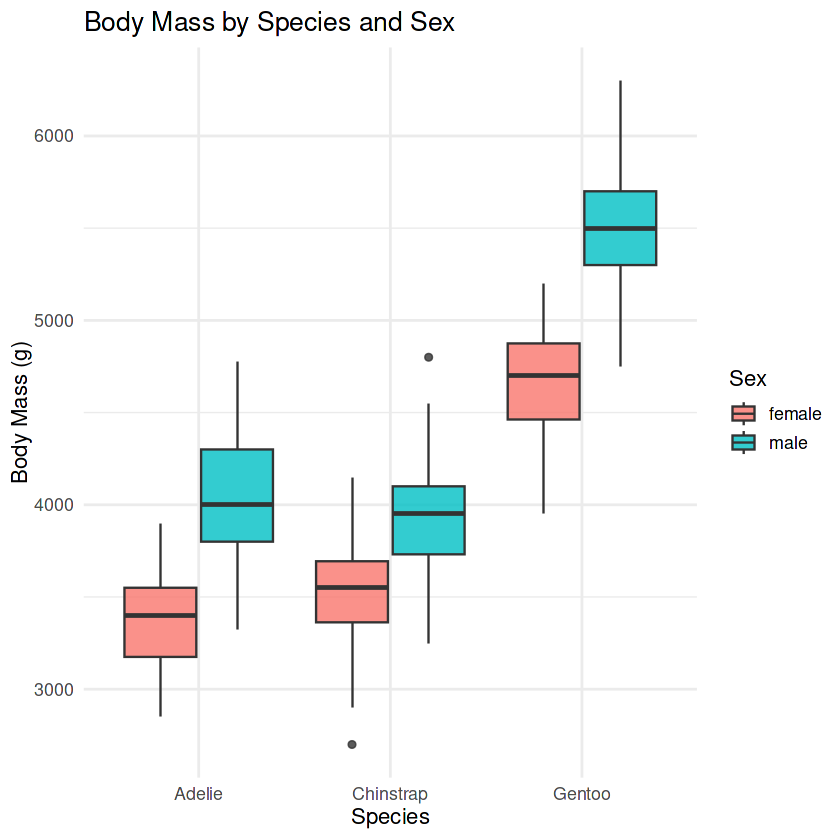

In [29]:
ggplot(two_way_data, aes(x = species, y = body_mass_g, fill = sex)) +
  geom_boxplot(position = position_dodge(width = 0.8), alpha = 0.8) +
  labs(
    title = "Body Mass by Species and Sex",
    x = "Species",
    y = "Body Mass (g)",
    fill = "Sex"
  )

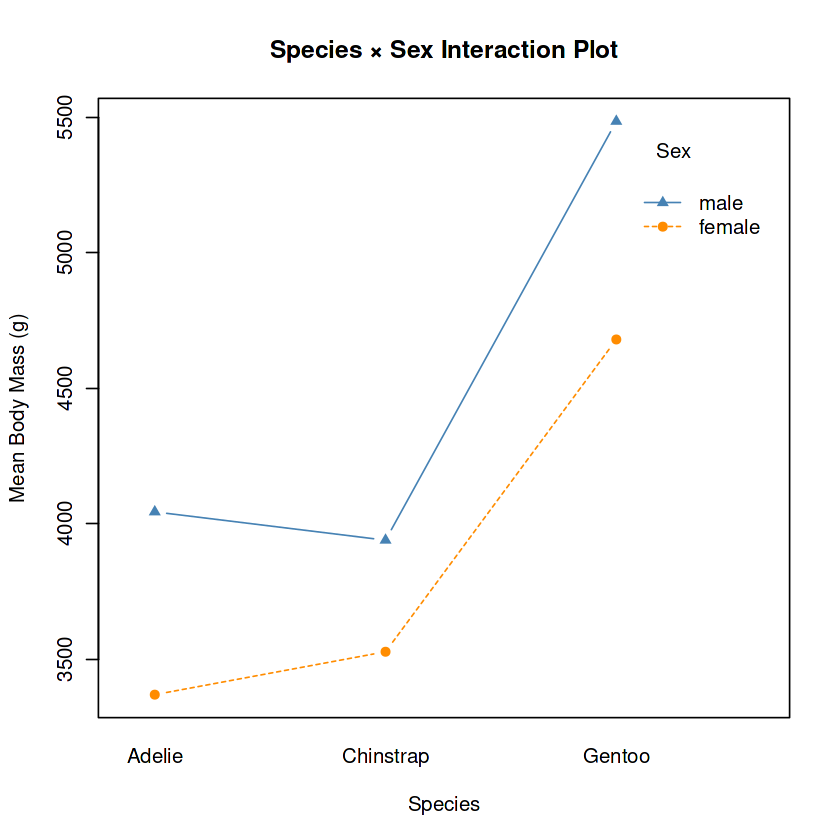

In [30]:
interaction.plot(
  x.factor = two_way_data$species,
  trace.factor = two_way_data$sex,
  response = two_way_data$body_mass_g,
  fun = mean,
  type = "b",
  col = c("darkorange", "steelblue"),
  pch = c(16, 17),
  xlab = "Species",
  ylab = "Mean Body Mass (g)",
  trace.label = "Sex",
  main = "Species × Sex Interaction Plot"
)

### Interpretation of Two-Way ANOVA

The species main effect determines whether average body mass differs among species after accounting for sex. The sex main effect determines whether males and females differ in body mass after accounting for species. The interaction tests whether the effect of sex depends on species.

A significant interaction would indicate that the male-female difference is not constant across species.

# 10. Additional Analysis: Flipper Length

The analysis is repeated for `flipper_length_mm` to determine whether flipper length varies significantly among the three penguin species.

In [31]:
flipper_data <- penguins %>%
  filter(!is.na(flipper_length_mm), !is.na(species))

flipper_stats <- flipper_data %>%
  group_by(species) %>%
  summarise(
    N = n(),
    Mean = mean(flipper_length_mm),
    Median = median(flipper_length_mm),
    SD = sd(flipper_length_mm),
    Minimum = min(flipper_length_mm),
    Maximum = max(flipper_length_mm),
    IQR = IQR(flipper_length_mm),
    .groups = "drop"
  )

kable(flipper_stats, digits = 3, caption = "Flipper length descriptive statistics")



Table: Flipper length descriptive statistics

|species   |   N|    Mean| Median|    SD| Minimum| Maximum| IQR|
|:---------|---:|-------:|------:|-----:|-------:|-------:|---:|
|Adelie    | 151| 189.954|    190| 6.539|     172|     210|   9|
|Chinstrap |  68| 195.824|    196| 7.132|     178|     212|  10|
|Gentoo    | 123| 217.187|    216| 6.485|     203|     231|   9|

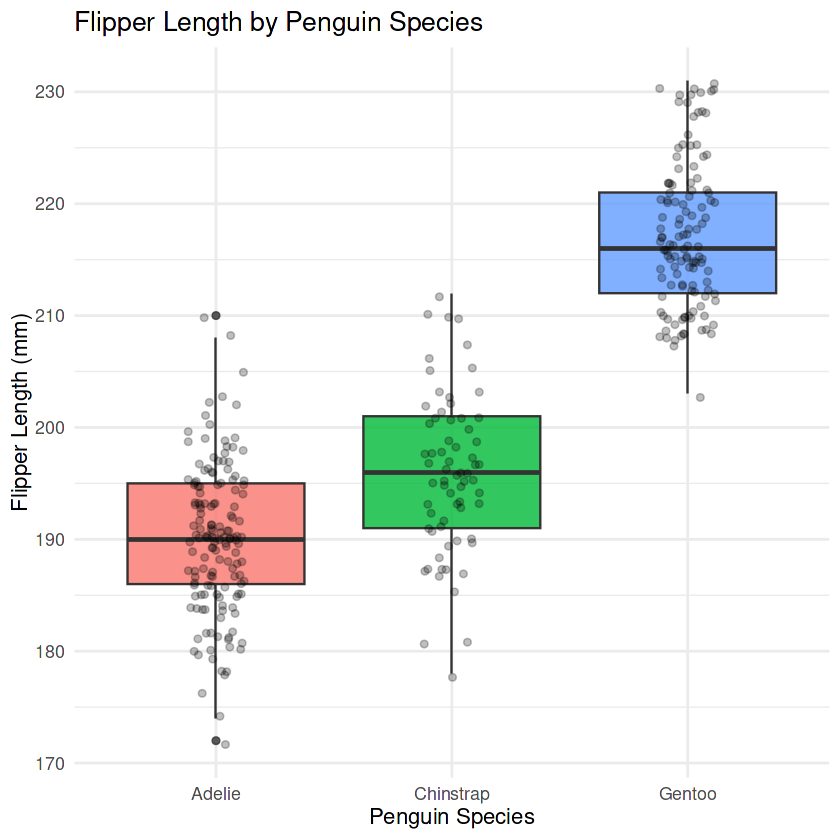

In [32]:
ggplot(flipper_data, aes(x = species, y = flipper_length_mm, fill = species)) +
  geom_boxplot(alpha = 0.8) +
  geom_jitter(width = 0.12, alpha = 0.25) +
  labs(
    title = "Flipper Length by Penguin Species",
    x = "Penguin Species",
    y = "Flipper Length (mm)"
  ) +
  theme(legend.position = "none")

In [33]:
flipper_shapiro <- flipper_data %>%
  group_by(species) %>%
  summarise(
    W = shapiro.test(flipper_length_mm)$statistic,
    p_value = shapiro.test(flipper_length_mm)$p.value,
    .groups = "drop"
  )

kable(flipper_shapiro, digits = 5, caption = "Flipper-length normality tests")



Table: Flipper-length normality tests

|species   |       W| p_value|
|:---------|-------:|-------:|
|Adelie    | 0.99339| 0.72005|
|Chinstrap | 0.98891| 0.81064|
|Gentoo    | 0.96219| 0.00162|

In [34]:
flipper_levene <- leveneTest(flipper_length_mm ~ species, data = flipper_data)
flipper_levene

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.3305621,0.7187511
,339,NA,NA


In [35]:
flipper_anova <- aov(flipper_length_mm ~ species, data = flipper_data)
        
        summary(flipper_anova)

             Df Sum Sq Mean Sq F value              Pr(>F)    
species       2  52473   26237   594.8 <0.0000000000000002 ***
Residuals   339  14953      44                                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [36]:
flipper_tukey <- TukeyHSD(flipper_anova)
flipper_tukey

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = flipper_data)

$species
                      diff       lwr       upr p adj
Chinstrap-Adelie  5.869887  3.586583  8.153191     0
Gentoo-Adelie    27.233349 25.334376 29.132323     0
Gentoo-Chinstrap 21.363462 19.000841 23.726084     0


In [37]:
flipper_kruskal <- kruskal.test(flipper_length_mm ~ species, data = flipper_data)
flipper_kruskal


	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 244.89, df = 2, p-value <
0.00000000000000022


# 11. Group Comparison Plot

The following plot displays species-level means with 95% confidence intervals for body mass.

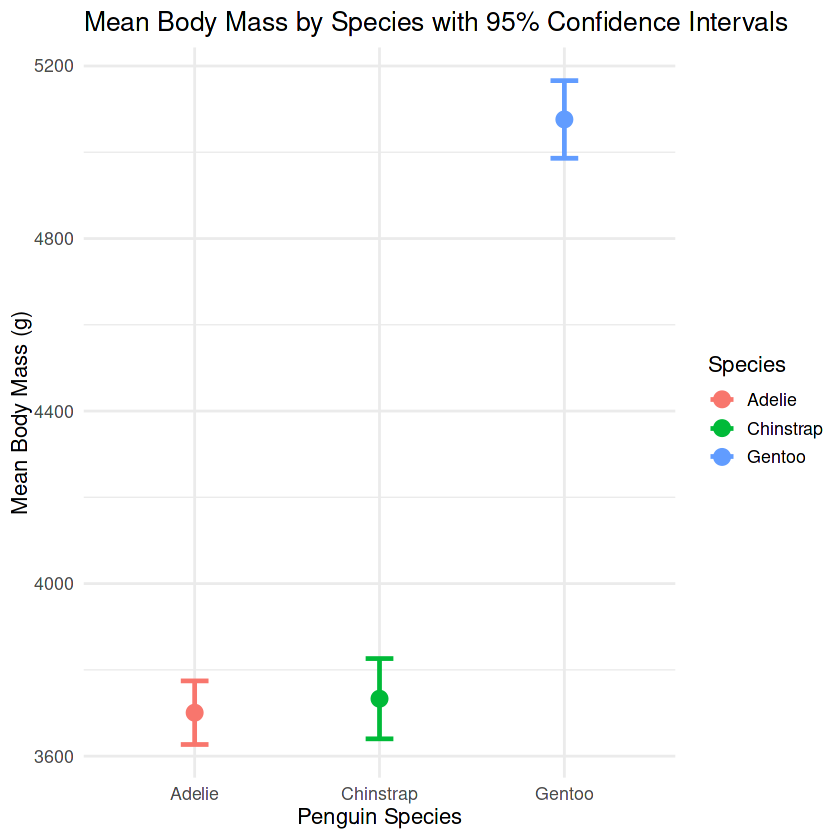

In [38]:
group_comparison <- species_mass %>%
  group_by(species) %>%
  summarise(
    n = n(),
    mean = mean(body_mass_g),
    sd = sd(body_mass_g),
    se = sd / sqrt(n),
    lower = mean - qt(0.975, df = n - 1) * se,
    upper = mean + qt(0.975, df = n - 1) * se,
    .groups = "drop"
  )

ggplot(group_comparison, aes(x = species, y = mean, color = species)) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, linewidth = 1) +
  labs(
    title = "Mean Body Mass by Species with 95% Confidence Intervals",
    x = "Penguin Species",
    y = "Mean Body Mass (g)",
    color = "Species"
  )

# 12. ANOVA Diagnostic Plots

Residual diagnostics are examined to evaluate whether the ANOVA model is reasonably appropriate.

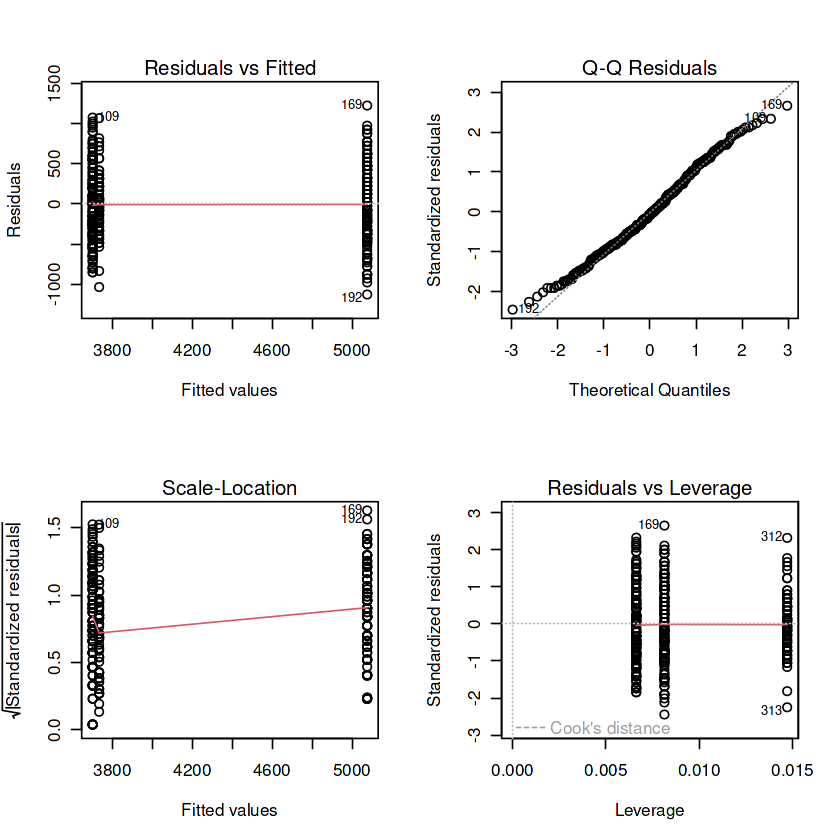

In [39]:
par(mfrow = c(2, 2))
plot(anova_oneway)
par(mfrow = c(1, 1))

# 13. Automated Statistical Summary

The following code extracts the main p-values and creates a concise conclusion for the report.

In [40]:
sex_p <- t_test_sex$p.value
anova_p <- summary(anova_oneway)[[1]][["Pr(>F)"]][1]
kw_p <- kruskal_species$p.value
two_way_p <- summary(anova_two_way)[[1]][["Pr(>F)"]]
flipper_p <- summary(flipper_anova)[[1]][["Pr(>F)"]][1]

cat("================ STATISTICAL SUMMARY ================\n")
cat("Male vs Female t-test p-value:", format.pval(sex_p), "\n")
cat("One-way ANOVA species p-value:", format.pval(anova_p), "\n")
cat("Kruskal-Wallis species p-value:", format.pval(kw_p), "\n")
cat("Two-way ANOVA species p-value:", format.pval(two_way_p[1]), "\n")
cat("Two-way ANOVA sex p-value:", format.pval(two_way_p[2]), "\n")
cat("Two-way ANOVA interaction p-value:", format.pval(two_way_p[3]), "\n")
cat("Flipper-length ANOVA p-value:", format.pval(flipper_p), "\n")

================ STATISTICAL SUMMARY ================
Male vs Female t-test p-value: 0.00000000000000047939 
One-way ANOVA species p-value: < 0.000000000000000222 
Kruskal-Wallis species p-value: < 0.000000000000000222 
Two-way ANOVA species p-value: < 0.000000000000000222 
Two-way ANOVA sex p-value: < 0.000000000000000222 
Two-way ANOVA interaction p-value: 0.00019735 
Flipper-length ANOVA p-value: < 0.000000000000000222 


# 14. Final Interpretation and Conclusion

## Body Mass and Sex

The independent two-sample t-test determines whether male and female penguins have significantly different mean body masses. The confidence interval provides the estimated range for the population mean difference, while Cohen's *d* describes the practical magnitude of the difference.

## Body Mass and Species

The one-way ANOVA tests whether mean body mass differs among Adélie, Chinstrap, and Gentoo penguins. If statistically significant, Tukey's HSD identifies the specific species pairs responsible for the difference.

The Kruskal-Wallis test provides a non-parametric comparison. Agreement between ANOVA and Kruskal-Wallis supports the robustness of the species-level conclusion.

## Species and Sex Together

The two-way ANOVA evaluates the independent effects of species and sex and whether the effect of sex changes according to species. The interaction term is particularly important for determining whether sexual differences in body mass are consistent across species.

## Flipper Length

The flipper-length analysis provides a second physical characteristic with which to compare species. Significant differences in flipper length, especially if the same species ordering is observed as for body mass, provide additional evidence that penguin species differ substantially in physical morphology.


# References

1. UCI Machine Learning Repository. Palmer Penguins Dataset, Dataset ID 690.
2. Gorman, K. B., Williams, T. D., & Fraser, W. R. (2014). Ecological Sexual Dimorphism and Environmental Variability within a Community of Antarctic Penguins (Genus Pygoscelis). *PLoS ONE*, 9(3), e90081.
3. Horst, A. M., Hill, A. P., & Gorman, K. B. Palmer Penguins dataset.
